## Notebook 4: Impact Functions

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
We pick a reference temperature, here 20°C where excess heat risk = 0. We choose anchor points for each of the age-bucket and we fit a power-law tail above 20°C that passes through anchor points. We convert the change deaths per 100k per day into per-person probability per day (mdd). So basically we get "if today's mean T is X, then in age group A there are ... extra heat-attributable deaths per 100k people compared to a comfortable 20°C day". The IF curves are about the marginal (heat) excess, not about all-cause baseline mortality. 
</blockquote>

In [2]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [3]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [4]:
cfg  = C.get("cfg")     # dict loaded from YAML

**from Notebook 3**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from climada.hazard import Hazard
from climada.entity.exposures import Exposures
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc

plt.rcParams.update({"figure.dpi": 130})

# loading hazard and exposure produced in Notebook 3
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"

H   = Hazard.from_hdf5(haz_path)
exp = Exposures.from_hdf5(exp_path)

# repairing daily metadata 
def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)

    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."

    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)

    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

H = reattach_daily_dates(INT, SLUG, H)
H.haz_type = "T2M"
H.units    = "degC (daily mean)"

H.write_hdf5(INT / f"hazard_T2M_daily_{SLUG}.h5")

yrs = pd.to_datetime(H.date).year.to_numpy(int)
print(pd.Series(yrs).value_counts().sort_index())
print(pd.DataFrame({"y": yrs, "f": H.frequency}).groupby("y")["f"].sum())

assert np.allclose(pd.DataFrame({"y": yrs, "f": H.frequency}).groupby("y")["f"].sum().values, 1.0)

if not hasattr(H, "date") or len(getattr(H, "date", [])) != H.intensity.shape[0]:
    raise RuntimeError("Daily dates not present in hazard. Re-run NB3 saving steps.")

# Event-year index from daily dates
dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
year_idx = dates.dt.year.to_numpy(int)  # length = n_days

2025-11-18 09:44:26,566 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
2030    365
2040    366
2050    365
Name: count, dtype: int64
y
2030    1.0
2040    1.0
2050    1.0
Name: f, dtype: float64


In [6]:
# H.intensity and H.fraction are sparse (events x cells)
num = H.intensity.multiply(H.fraction).sum(axis=1)   # sum of T over valid cells
den = H.fraction.sum(axis=1)                         # number of valid cells
citymean_daily = (num / den).A1                      # 1D array (length = n_days)

pd.DataFrame({"date": dates, "citymean_degC": citymean_daily}).head(10)

,date,citymean_degC
0,2030-01-01,9.104262
1,2030-01-02,8.832363
2,2030-01-03,7.696796
3,2030-01-04,8.188349
4,2030-01-05,8.228600
5,2030-01-06,8.441196
6,2030-01-07,9.083479
7,2030-01-08,9.242881
8,2030-01-09,9.368395
9,2030-01-10,9.557694


sanity plot of the daily city-mean temps

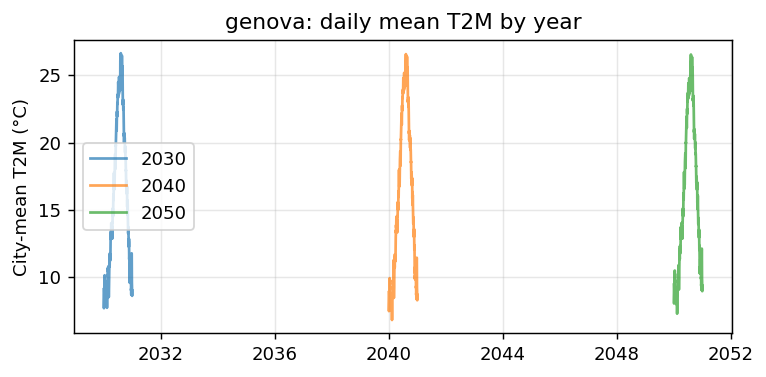

In [7]:
# daily city-mean T2M per year (just for intuition)
daily_df = pd.DataFrame({"date": dates, "citymean_degC": citymean_daily})
daily_df["year"] = daily_df["date"].dt.year

fig, ax = plt.subplots(figsize=(6,3))
for y, sub in daily_df.groupby("year"):
    ax.plot(sub["date"], sub["citymean_degC"], label=y, alpha=0.7)
ax.set_ylabel("City-mean T2M (°C)")
ax.set_title(f"{CITY}: daily mean T2M by year")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Temperature grid for impact functions

In [8]:
# Intensity axis for all T2M impact functions (0–40 °C)
t_min, t_max, t_step = 0.0, 40.0, 0.5
T_grid = np.arange(t_min, t_max + 1e-6, t_step)  # °C
T_ref  = 20.0  # "comfortable" temperature, where excess risk is around 0

Helper to build a “heat-only” tail: change indeaths per 100k to daily probability

Approximation of each of the curve as a smooth power-law tail above 20 °C that matches a couple of points from the EU figure, then convert “extra deaths per 100,000 people per hot day” into a fraction of people dying that day.

In [9]:
def heat_tail_power(T, T_ref, d1, T1, d2, T2):
    """
    Constructing a convex 'heat-only' curve:
      change deaths per 100k = beta * (T - T_ref)^p  for T > T_ref, else 0
    passing approximately through (T1, d1) and (T2, d2).
    """
    # distance above reference
    h1 = max(T1 - T_ref, 1e-6)
    h2 = max(T2 - T_ref, 1e-6)
    # exponent from the two target points
    p = np.log(d2 / d1) / np.log(h2 / h1)
    beta = d1 / (h1 ** p)
    out = np.zeros_like(T, dtype=float)
    h = np.clip(T - T_ref, 0, None)
    out = beta * np.power(h, p)
    return out, beta, p

We choose rough “anchor points” mimicking the EU panel

- Elderly: about 1 extra death/100k at around 28 °C, around 12 at around 35 °C.

- Adults: about 0.1 at 28 °C, 0.4 at 35 °C.

- Young: tiny effect, say 0.02 at 28 °C, 0.05 at 35 °C.

In [10]:
# Elderly (65+)
elderly_d, elderly_beta, elderly_p = heat_tail_power(
    T_grid, T_ref,
    d1=0.3,  T1=24.0,   # 0.3 per 100k at 24°C
    d2=12.0, T2=35.0    # 12 per 100k at 35°C
)

# Adults (15–64)
adult_d, adult_beta, adult_p = heat_tail_power(
    T_grid, T_ref,
    d1=0.10, T1=28.0,   # 0.1 per 100k at 28°C
    d2=0.40, T2=35.0    # 0.4 per 100k at 35°C
)

# Young (<15)
young_d, young_beta, young_p = heat_tail_power(
    T_grid, T_ref,
    d1=0.02, T1=28.0,   
    d2=0.05, T2=35.0
)

# converting change in deaths per 100k per day to probability per person per day (fraction)
per100k = 100_000.0
elderly_mdd = elderly_d / per100k
adult_mdd   = adult_d   / per100k
young_mdd   = young_d   / per100k

# making sure we never exceed 1 
elderly_mdd = np.clip(elderly_mdd, 0, 1)
adult_mdd   = np.clip(adult_mdd,   0, 1)
young_mdd   = np.clip(young_mdd,   0, 1)

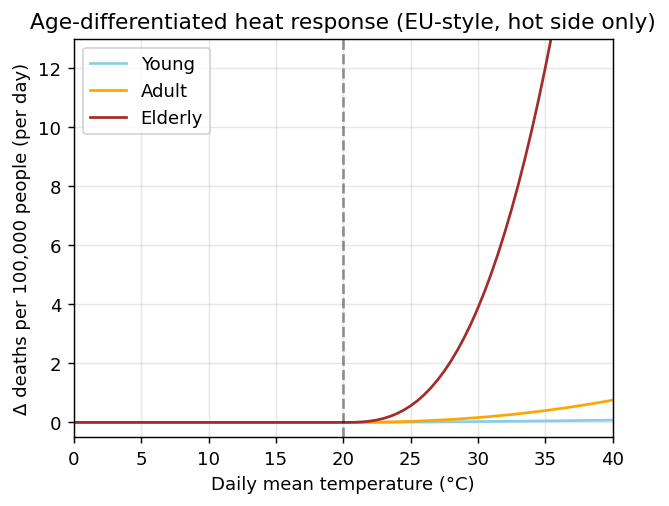

Elderly curve parameters: beta = 0.006264, p = 2.791
Adult   curve parameters: beta = 0.001019, p = 2.205
Young   curve parameters: beta = 0.0009653, p = 1.458


In [11]:
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(T_grid, young_d,   label="Young",  color="skyblue")
ax.plot(T_grid, adult_d,   label="Adult",  color="orange")
ax.plot(T_grid, elderly_d, label="Elderly",color="brown")
ax.axvline(T_ref, color="k", linestyle="--", alpha=0.4)
ax.set_xlim(0, 40)
ax.set_ylim(-0.5, 13)
ax.set_xlabel("Daily mean temperature (°C)")
ax.set_ylabel("Δ deaths per 100,000 people (per day)")
ax.set_title("Age-differentiated heat response (EU-style, hot side only)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("Elderly curve parameters: beta = %.4g, p = %.3f" % (elderly_beta, elderly_p))
print("Adult   curve parameters: beta = %.4g, p = %.3f" % (adult_beta, adult_p))
print("Young   curve parameters: beta = %.4g, p = %.3f" % (young_beta, young_p))

Age-group populations

In [12]:
age_pop = (
    exp.gdf
       .groupby("age_group")["value"]
       .sum()
       .astype(float)
       .sort_index()
)

print("Population by age group (T2M grid):")
print(age_pop)
print("Total population:", float(age_pop.sum()))

Population by age group (T2M grid):
age_group
15-64    334769.043136
65+      188747.155729
<15       53033.567462
Name: value, dtype: float64
Total population: 576549.766326806


Building interpolation helpers for the curves

In [13]:
import numpy as np
import pandas as pd

# Mapping age group to curve in "deaths per 100k per day"
curves_per100k = {
    "<15":   young_d,
    "15-64": adult_d,
    "65+":   elderly_d,
}

def delta_deaths_per100k(T):
    """
    Return a dict {age_group: Δ deaths per 100k per day} 
    for a scalar temperature T (°C).
    """
    out = {}
    for age, curve in curves_per100k.items():
        out[age] = float(np.interp(T, T_grid, curve))
    return out

Turning daily temps into daily excess deaths

In [14]:
# Build a DataFrame with one row per day
df = pd.DataFrame({
    "date": dates,
    "temp_degC": citymean_daily,
})
df["year"] = df["date"].dt.year

rows = []
for _, row in df.iterrows():
    T = row["temp_degC"]
    y = row["year"]
    d_per100k = delta_deaths_per100k(T)
    for age in ["<15", "15-64", "65+"]:
        deaths_day = d_per100k[age] * (age_pop[age] / 100_000.0)
        rows.append({
            "date":  row["date"],
            "year":  y,
            "age_group": age,
            "temp_degC": T,
            "delta_deaths": deaths_day,
        })

daily_heat = pd.DataFrame(rows)

In [15]:
daily_heat = pd.DataFrame(rows)

# See the first few days
print(daily_heat.head())

        date  year age_group  temp_degC  delta_deaths
0 2030-01-01  2030       <15   9.104262           0.0
1 2030-01-01  2030     15-64   9.104262           0.0
2 2030-01-01  2030       65+   9.104262           0.0
3 2030-01-02  2030       <15   8.832363           0.0
4 2030-01-02  2030     15-64   8.832363           0.0


In [17]:
# Yearly deaths by age group
yearly = (
    daily_heat
    .groupby(["year", "age_group"])["delta_deaths"]
    .sum()
    .unstack("age_group")          # columns: '<15', '15-64', '65+'
    .fillna(0.0)
)

# renaming columns 
yearly = yearly.rename(
    columns={
        "<15":   "deaths_young",
        "15-64": "deaths_adult",
        "65+":   "deaths_elderly",
    }
)

# adding total across ages
yearly["deaths_total"] = (
    yearly["deaths_young"]
    + yearly["deaths_adult"]
    + yearly["deaths_elderly"]
)

print(yearly)

age_group  deaths_adult  deaths_elderly  deaths_young  deaths_total
year                                                               
2030           8.084479       70.425606      0.389001     78.899086
2040           8.676801       75.562011      0.415953     84.654765
2050           8.009183       68.784802      0.392380     77.186365


Aggregate to annual totals and rates per 100k

In [18]:
# Annual deaths by age group
annual_by_age = (
    daily_heat
    .groupby(["year", "age_group"])["delta_deaths"]
    .sum()
    .unstack("age_group")
)

print("Annual heat deaths (absolute):")
print(annual_by_age)

# Annual rates per 100k in each age group
annual_rates_per100k = annual_by_age.copy()
for age in ["<15", "15-64", "65+"]:
    annual_rates_per100k[age] = (
        annual_by_age[age] / (age_pop[age] / 100_000.0)
    )

print("\nAnnual heat deaths per 100k, by age group:")
print(annual_rates_per100k)

Annual heat deaths (absolute):
age_group     15-64        65+       <15
year                                    
2030       8.084479  70.425606  0.389001
2040       8.676801  75.562011  0.415953
2050       8.009183  68.784802  0.392380

Annual heat deaths per 100k, by age group:
age_group     15-64        65+       <15
year                                    
2030       2.414942  37.312141  0.733500
2040       2.591877  40.033457  0.784320
2050       2.392450  36.442828  0.739871


**Into CLIMADA: pixel-wise, not city-mean anymore**

In [19]:
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet

# making sure T_grid and *_mdd are numpy arrays
T_arr      = np.asarray(T_grid, float)
young_arr  = np.asarray(young_mdd, float)
adult_arr  = np.asarray(adult_mdd, float)
elderly_arr= np.asarray(elderly_mdd, float)

# sanity check (monotone, between 0 and 1)
for lbl, arr in [("<15", young_arr), ("15-64", adult_arr), ("65+", elderly_arr)]:
    assert np.all(arr >= 0) and np.all(arr <= 1), f"{lbl} mdd outside [0,1]"

age_ifs = {
    "<15": ImpactFunc(
        haz_type="T2M",
        id=1,
        intensity=T_arr,
        mdd=young_arr,
        paa=np.ones_like(T_arr),
        name="<15",
    ),
    "15-64": ImpactFunc(
        haz_type="T2M",
        id=2,
        intensity=T_arr,
        mdd=adult_arr,
        paa=np.ones_like(T_arr),
        name="15–64",
    ),
    "65+": ImpactFunc(
        haz_type="T2M",
        id=3,
        intensity=T_arr,
        mdd=elderly_arr,
        paa=np.ones_like(T_arr),
        name="65+",
    ),
}

ifs = ImpactFuncSet(list(age_ifs.values()))
ifs.check()  # will raise if something is inconsistent
print("Built age-specific T2M impact functions:", [f"{k}→{v.id}" for k, v in age_ifs.items()])

Built age-specific T2M impact functions: ['<15→1', '15-64→2', '65+→3']


In [20]:
from climada.engine import ImpactCalc

# mapping age label to IF id
age_to_if_id = {
    "<15": 1,
    "15-64": 2,
    "65+": 3,
}

# Year index from hazard dates
year_idx = pd.to_datetime(H.date.astype("datetime64[ns]")).year

climada_annual = {}

for age_lbl in ["<15", "15-64", "65+"]:
    # copying exposures and zero out everyone not in this age group
    exp_age = exp.copy()
    mask = (exp_age.gdf["age_group"] == age_lbl)
    
    # people not in this age group to 0 persons
    exp_age.gdf.loc[~mask, "value"] = 0.0
    
    # assign the right IF id only for this age group
    exp_age.gdf["if_T2M"] = 0
    exp_age.gdf.loc[mask, "if_T2M"] = age_to_if_id[age_lbl]

    # running ImpactCalc: this returns deaths per event in this age group
    imp = ImpactCalc(exp_age, ifs, H).impact(save_mat=False)

    # aggregating to yearly totals (sum of deaths over all days in that year)
    daily_deaths = pd.Series(imp.at_event)  # one value per day/event
    annual_deaths = daily_deaths.groupby(year_idx).sum()

    climada_annual[age_lbl] = annual_deaths

In [21]:
print("Annual heat deaths (absolute):")
print(annual_by_age)

Annual heat deaths (absolute):
age_group     15-64        65+       <15
year                                    
2030       8.084479  70.425606  0.389001
2040       8.676801  75.562011  0.415953
2050       8.009183  68.784802  0.392380


In [22]:
compare = []

for age_lbl in ["<15", "15-64", "65+"]:
    s_manual = annual_by_age[age_lbl]
    s_clim   = climada_annual[age_lbl]
    df_cmp = pd.DataFrame({
        "manual": s_manual,
        "climada": s_clim,
        "diff": s_clim - s_manual,
        "rel_diff_%": 100 * (s_clim - s_manual) / s_manual
    })
    print(f"\n=== Age group {age_lbl} ===")
    print(df_cmp)
    compare.append(df_cmp)


=== Age group <15 ===
        manual   climada      diff  rel_diff_%
2030  0.389001  0.376470 -0.012531   -3.221421
2040  0.415953  0.401614 -0.014339   -3.447201
2050  0.392380  0.378703 -0.013677   -3.485685

=== Age group 15-64 ===
        manual   climada      diff  rel_diff_%
2030  8.084479  8.144852  0.060373    0.746775
2040  8.676801  8.721568  0.044767    0.515934
2050  8.009183  8.069197  0.060015    0.749324

=== Age group 65+ ===
         manual    climada      diff  rel_diff_%
2030  70.425606  73.986049  3.560444    5.055610
2040  75.562011  79.258425  3.696414    4.891895
2050  68.784802  72.434007  3.649205    5.305248


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
why the small differences? citymean_daily: turning each day's T into a change in deaths per 100k using power-law curves. Then, multiplying by age-group population and sum days to get annual_by age. CLIMADA uses the full T2M grid (H.intensity) with spatial variation, applies the same mdd(T) via ImpactFunc per pixel and multiply by pixel-level persons, sum over grid and days to give us climada_annual. It's this that we use later for the impacts. So the "manual" uses single city-mean T while CLIMADA uses each pixel's T.  
</blockquote>

**Saving for later**

In [23]:
import json
from pathlib import Path

# Converting IFs to a simple dict structure
freeze_dict = {}
for age_lbl, f in age_ifs.items():
    freeze_dict[age_lbl] = {
        "id": int(f.id),
        "name": f.name,
        "intensity": np.asarray(f.intensity, float).tolist(),
        "mdd":       np.asarray(f.mdd,       float).tolist(),
    }

freeze_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
with open(freeze_path, "w") as fh:
    json.dump(freeze_dict, fh, indent=2)

print("Wrote age-differentiated IFs to:", freeze_path)

Wrote age-differentiated IFs to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/if_curves_frozen_genova.json


**Baseline deaths**

Wittgenstein data

In [27]:
import pandas as pd
from pathlib import Path

# Path to file
baseline_csv = Path(BASE) / "baselinedeaths.csv"
df_b = pd.read_csv(baseline_csv)

print(df_b.head())

   year age_group  deaths_per_100k
0  2030       <15              5.8
1  2030     15-64            154.9
2  2030       65+           3427.1
3  2040       <15              3.4
4  2040     15-64            106.9


In [28]:
df_b = df_b.rename(columns={
    "Year": "year",
    "age": "age_group",
    "agegroup": "age_group",
    "baseline": "deaths_per_100k",
    "baseline_deaths": "deaths_per_100k"
})

# Make sure correct dtypes
df_b["year"] = df_b["year"].astype(int)
df_b["deaths_per_100k"] = df_b["deaths_per_100k"].astype(float)

# Keep only the age groups used in IFs
valid_ages = {"<15", "15-64", "65+"}
df_b = df_b[df_b["age_group"].isin(valid_ages)]

In [29]:
baseline_mort = (
    df_b
    .pivot(index="year", columns="age_group", values="deaths_per_100k")
    .sort_index()
)

print("Baseline mortality table:")
display(baseline_mort)

Baseline mortality table:


age_group,15-64,65+,<15
year,,,
2030,154.9,3427.1,5.8
2040,106.9,3057.2,3.4
2050,70.1,3129.1,1.7


In [30]:
ref_year = 2030
if ref_year not in baseline_mort.index:
    ref_year = baseline_mort.index.min()

scale_factors = baseline_mort / baseline_mort.loc[ref_year]

scale_factors says, for each age and year, how baseline mortality compares to the reference year.

In [31]:
def apply_baseline_scaling(heat_df, scale_factors, use_scaling=True):
    if not use_scaling:
        return heat_df.copy()
    
    out = heat_df.copy()
    ages = ["<15", "15-64", "65+"]
    
    for y in out.index:
        if y in scale_factors.index:
            for a in ages:
                out.loc[y, a] *= scale_factors.loc[y, a]
    return out

heat_scaled = apply_baseline_scaling(annual_by_age, scale_factors)
display(heat_scaled)

age_group,15-64,65+,<15
year,,,
2030,8.084479,70.425606,0.389001
2040,5.988057,67.406314,0.243835
2050,3.624556,62.803690,0.115008


heat_scaled is scenario where heat mortality changes in proportion to baseline mortality (“people get less/more sensitive over time” assumption)

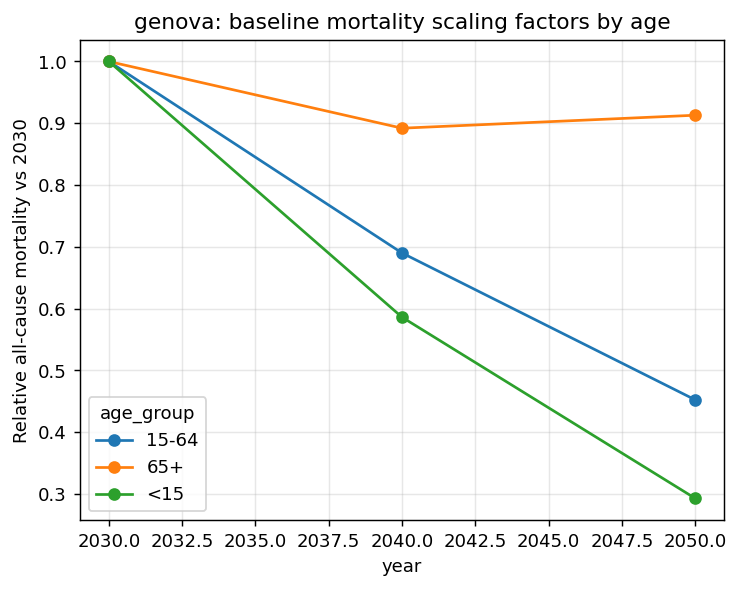

In [32]:
scale_factors.plot(marker="o")
plt.ylabel("Relative all-cause mortality vs 2030")
plt.title(f"{CITY}: baseline mortality scaling factors by age")
plt.grid(alpha=0.3)
plt.show()

Same for CLIMADA

In [33]:
# climada_annual is currently: { "<15": Series, "15-64": Series, "65+": Series }
annual_by_age_climada = pd.DataFrame(climada_annual)
annual_by_age_climada = annual_by_age_climada[["15-64", "65+", "<15"]]  # just to order columns 

print("CLIMADA annual heat deaths (absolute):")
display(annual_by_age_climada)

CLIMADA annual heat deaths (absolute):


,15-64,65+,<15
2030,8.144852,73.986049,0.376470
2040,8.721568,79.258425,0.401614
2050,8.069197,72.434007,0.378703


In [34]:
# baseline mortality scaling to CLIMADA deaths 

use_scaling = True  

climada_scaled = apply_baseline_scaling(annual_by_age_climada, scale_factors, use_scaling=use_scaling)

print("CLIMADA annual heat deaths after baseline scaling:")
display(climada_scaled)

CLIMADA annual heat deaths after baseline scaling:


,15-64,65+,<15
2030,8.144852,73.986049,0.376470
2040,6.018951,70.703760,0.235429
2050,3.651716,66.135581,0.110999


In [35]:
# per-100k rates for CLIMADA, before and after scaling 

def per100k_from_df(df, age_pop):
    out = df.copy()
    for age in ["<15", "15-64", "65+"]:
        out[age] = df[age] / (age_pop[age] / 100_000.0)
    return out

climada_rates_per100k          = per100k_from_df(annual_by_age_climada, age_pop)
climada_scaled_rates_per100k   = per100k_from_df(climada_scaled,          age_pop)

print("CLIMADA annual heat deaths per 100k, by age group (no baseline scaling):")
display(climada_rates_per100k)

print("CLIMADA annual heat deaths per 100k, by age group (with baseline scaling):")
display(climada_scaled_rates_per100k)

CLIMADA annual heat deaths per 100k, by age group (no baseline scaling):


,15-64,65+,<15
2030,2.432977,39.198498,0.709871
2040,2.605249,41.991851,0.757283
2050,2.410377,38.376211,0.714082


CLIMADA annual heat deaths per 100k, by age group (with baseline scaling):


,15-64,65+,<15
2030,2.432977,39.198498,0.709871
2040,1.797941,37.459510,0.443925
2050,1.090816,35.039247,0.209300


In [36]:
# comparison table: CLIMADA with vs without scaling 

for age in ["<15", "15-64", "65+"]:
    cmp = pd.DataFrame({
        "no_scaling":  annual_by_age_climada[age],
        "with_scaling": climada_scaled[age],
    })
    print(f"\n=== Age group {age} ===")
    display(cmp)


=== Age group <15 ===


,no_scaling,with_scaling
2030,0.376470,0.376470
2040,0.401614,0.235429
2050,0.378703,0.110999



=== Age group 15-64 ===


,no_scaling,with_scaling
2030,8.144852,8.144852
2040,8.721568,6.018951
2050,8.069197,3.651716



=== Age group 65+ ===


,no_scaling,with_scaling
2030,73.986049,73.986049
2040,79.258425,70.703760
2050,72.434007,66.135581


Now, later we can apply or not the scale when calculating the impacts

**saving**

In [37]:
from pathlib import Path

# baseline scaling factors 
sf_path = Path(INT) / f"baseline_heat_scaling_{SLUG}.csv"
scale_factors.to_csv(sf_path)
print("Saved scaling factors →", sf_path)

# manual (city-mean) heat deaths: raw and scaled
manual_raw_path = Path(INT) / f"annual_heat_deaths_manual_{SLUG}.csv"
manual_scaled_path = Path(INT) / f"annual_heat_deaths_manual_scaled_{SLUG}.csv"

annual_by_age.to_csv(manual_raw_path)
heat_scaled.to_csv(manual_scaled_path)

print("Saved manual annual heat deaths (raw)   →", manual_raw_path)
print("Saved manual annual heat deaths (scaled)→", manual_scaled_path)

# CLIMADA heat deaths: raw and scaled
climada_raw_path = Path(INT) / f"annual_heat_deaths_climada_{SLUG}.csv"
climada_scaled_path = Path(INT) / f"annual_heat_deaths_climada_scaled_{SLUG}.csv"

annual_by_age_climada.to_csv(climada_raw_path)
climada_scaled.to_csv(climada_scaled_path)

print("Saved CLIMADA annual heat deaths (raw)   →", climada_raw_path)
print("Saved CLIMADA annual heat deaths (scaled)→", climada_scaled_path)

Saved scaling factors → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/baseline_heat_scaling_genova.csv
Saved manual annual heat deaths (raw)   → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_manual_genova.csv
Saved manual annual heat deaths (scaled)→ /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_manual_scaled_genova.csv
Saved CLIMADA annual heat deaths (raw)   → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_climada_genova.csv
Saved CLIMADA annual heat deaths (scaled)→ /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_climada_scaled_genova.csv
